# Trade Impact Analysis

This notebook measures how each trade affects a team's record and betting-market win odds within the same season.

It builds a trade-level impact score, ranks trades by season, and trains a random forest to identify which metrics are most associated with the highest-impact trades.

## Assumptions

- Games before the trade date are treated as the pre-trade window.
- Games on or after the trade date are treated as the post-trade window because the data does not include transaction times.
- If a trade happens before a team's first game in that season, the previous season is used as the baseline.
- Closing spread lines are used to calibrate a spread-to-win-probability model, and that calibration is reused for initial and SC spread lines.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
pd.set_option('display.max_rows', 200)

RANDOM_STATE = 42

In [30]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'games.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find the repository root that contains data/games.csv')

ROOT = find_repo_root()
DATA_DIR = ROOT / 'data'

games = pd.read_csv(DATA_DIR / 'games.csv')
trades = pd.read_csv(DATA_DIR / 'trades.csv')
initial_lines = pd.read_csv(DATA_DIR / 'initial_lines.csv')
closing_lines = pd.read_csv(DATA_DIR / 'closing_lines.csv')
sc_lines = pd.read_csv(DATA_DIR / 'sc_lines.csv')

games['game_date'] = pd.to_datetime(games['gameday'])
trades['trade_date'] = pd.to_datetime(trades['trade_date'])
games['home_win'] = (games['home_score'] > games['away_score']).astype(int)
games['away_win'] = (games['away_score'] > games['home_score']).astype(int)

print("Games DataFrame Info:")
print(games.info())
print("Games DataFrame Head:")
print(games.head(3))

print("\nTrades DataFrame Info:")
print(trades.info())
print("Trades DataFrame Head:")
print(trades.head(3))

print("\nInitial Lines DataFrame Info:")
print(initial_lines.info())
print("Initial Lines DataFrame Head:")
print(initial_lines.head(3))

print("\nClosing Lines DataFrame Info:")
print(closing_lines.info())
print("Closing Lines DataFrame Head:")
print(closing_lines.head(3))

print("\nSC Lines DataFrame Info:")
print(sc_lines.info())
print("SC Lines DataFrame Head:")
print(sc_lines.head(3))



Games DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7548 entries, 0 to 7547
Data columns (total 49 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   game_id           7548 non-null   object        
 1   season            7548 non-null   int64         
 2   game_type         7548 non-null   object        
 3   week              7548 non-null   int64         
 4   gameday           7548 non-null   object        
 5   weekday           7548 non-null   object        
 6   gametime          7289 non-null   object        
 7   away_team         7548 non-null   object        
 8   away_score        7276 non-null   float64       
 9   home_team         7548 non-null   object        
 10  home_score        7276 non-null   float64       
 11  location          7548 non-null   object        
 12  result            7276 non-null   float64       
 13  total             7276 non-null   float64       
 14  ov

In [31]:
def implied_prob_from_american(odds):
    if pd.isna(odds):
        return np.nan
    odds = float(odds)
    if odds == 0:
        return np.nan
    if odds < 0:
        return (-odds) / ((-odds) + 100.0)
    return 100.0 / (odds + 100.0)

def safe_mean(series):
    if len(series) == 0:
        return np.nan
    value = series.mean()
    return float(value) if pd.notna(value) else np.nan

def summarize_window(df):
    return {
        'games': int(len(df)),
        'wins': int(df['win'].sum()) if len(df) else 0,
        'losses': int((1 - df['win']).sum()) if len(df) else 0,
        'win_pct': safe_mean(df['win']),
        'point_diff_per_game': safe_mean(df['point_diff']),
        'initial_win_prob': safe_mean(df['initial_win_prob']),
        'closing_win_prob': safe_mean(df['closing_win_prob']),
        'sc_win_prob': safe_mean(df['sc_win_prob'])
    }

In [32]:
away_games = games[[
    'game_id', 'season', 'game_date', 'away_team', 'home_team',
    'away_score', 'home_score', 'away_win'
]].copy()
away_games['team'] = away_games['away_team']
away_games['opponent'] = away_games['home_team']
away_games['is_home'] = 0
away_games['win'] = away_games['away_win']
away_games['points_for'] = away_games['away_score']
away_games['points_against'] = away_games['home_score']
away_games['point_diff'] = away_games['points_for'] - away_games['points_against']

home_games = games[[
    'game_id', 'season', 'game_date', 'away_team', 'home_team',
    'away_score', 'home_score', 'home_win'
]].copy()
home_games['team'] = home_games['home_team']
home_games['opponent'] = home_games['away_team']
home_games['is_home'] = 1
home_games['win'] = home_games['home_win']
home_games['points_for'] = home_games['home_score']
home_games['points_against'] = home_games['away_score']
home_games['point_diff'] = home_games['points_for'] - home_games['points_against']

team_games = pd.concat([away_games, home_games], ignore_index=True, sort=False)
team_games = team_games.sort_values(['season', 'team', 'game_date', 'game_id']).reset_index(drop=True)

closing_spread_train = closing_lines.loc[closing_lines['type'] == 'SPREAD', ['alt_game_id', 'side', 'line']].merge(
    games[['game_id', 'away_team', 'home_team', 'away_win', 'home_win']],
    left_on=['alt_game_id'],
    right_on=['game_id'],
    how='left'
)
closing_spread_train['win'] = np.where(
    closing_spread_train['side'] == closing_spread_train['away_team'],
    closing_spread_train['away_win'],
    closing_spread_train['home_win']
)
closing_spread_train = closing_spread_train.dropna(subset=['line', 'win']).copy()

spread_probability_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LogisticRegression(max_iter=1000))
])
spread_probability_model.fit(closing_spread_train[['line']], closing_spread_train['win'])

def spread_win_probability(line_series):
    line_frame = line_series.rename('line').to_frame()
    values = spread_probability_model.predict_proba(line_frame)[:, 1]
    return pd.Series(values, index=line_series.index)

initial_spread = initial_lines.loc[initial_lines['type'] == 'SPREAD', ['about', 'side', 'line']].rename(
    columns={'about': 'game_id', 'side': 'team', 'line': 'initial_line'}
)
closing_spread = closing_lines.loc[closing_lines['type'] == 'SPREAD', ['alt_game_id', 'side', 'line']].rename(
    columns={'side': 'team', 'line': 'closing_spread_line'}
)
closing_moneyline = closing_lines.loc[closing_lines['type'] == 'MONEYLINE', ['alt_game_id', 'side', 'odds']].rename(
    columns={'side': 'team', 'odds': 'moneyline_odds'}
)
closing_moneyline['raw_moneyline_prob'] = closing_moneyline['moneyline_odds'].map(implied_prob_from_american)
closing_moneyline['closing_moneyline_prob'] = closing_moneyline.groupby('alt_game_id')['raw_moneyline_prob'].transform(
    lambda s: s / s.sum() if s.sum() > 0 else s
)
sc_spread = sc_lines[['season', 'away_team', 'home_team', 'side', 'line']].rename(
    columns={'side': 'team', 'line': 'sc_line'}
)

team_games = team_games.merge(initial_spread, on=['game_id', 'team'], how='left')
team_games = team_games.merge(closing_spread, left_on=['game_id', 'team'], right_on=['alt_game_id', 'team'], how='left')
team_games = team_games.merge(closing_moneyline[['alt_game_id', 'team', 'closing_moneyline_prob']], left_on=['game_id', 'team'], right_on=['alt_game_id', 'team'], how='left')
team_games = team_games.merge(sc_spread, on=['season', 'away_team', 'home_team', 'team'], how='left')

team_games['initial_win_prob'] = spread_win_probability(team_games['initial_line'])
team_games['closing_spread_prob'] = spread_win_probability(team_games['closing_spread_line'])
team_games['sc_win_prob'] = spread_win_probability(team_games['sc_line'])
team_games['closing_win_prob'] = team_games['closing_moneyline_prob'].where(
    team_games['closing_moneyline_prob'].notna(),
    team_games['closing_spread_prob']
)

source_coverage = pd.DataFrame({
    'source': ['initial', 'closing_moneyline', 'closing_spread', 'sc'],
    'coverage_pct': [
        team_games['initial_win_prob'].notna().mean(),
        team_games['closing_moneyline_prob'].notna().mean(),
        team_games['closing_spread_prob'].notna().mean(),
        team_games['sc_win_prob'].notna().mean()
    ]
})

source_coverage

,source,coverage_pct
0,initial,1.000000
1,closing_moneyline,0.444003
2,closing_spread,1.000000
3,sc,1.000000


In [33]:
trade_team_rows = []

for trade_id, trade_rows in trades.groupby('trade_id', sort=False):
    season = int(trade_rows['season'].iloc[0])
    trade_date = pd.to_datetime(trade_rows['trade_date'].min())
    participants = pd.Index(pd.concat([trade_rows['gave'], trade_rows['received']], ignore_index=True).dropna().astype(str).unique())

    for team in participants:
        current_season = team_games[(team_games['season'] == season) & (team_games['team'] == team)].sort_values('game_date')
        pre = current_season[current_season['game_date'] < trade_date].copy()
        post = current_season[current_season['game_date'] >= trade_date].copy()

        baseline_source = 'in_season_pre'
        if pre.empty:
            baseline_source = 'prior_season_full'
            pre = team_games[(team_games['season'] == season - 1) & (team_games['team'] == team)].sort_values('game_date').copy()

        pre_summary = summarize_window(pre)
        post_summary = summarize_window(post)

        delta_win_pct = post_summary['win_pct'] - pre_summary['win_pct'] if pd.notna(pre_summary['win_pct']) and pd.notna(post_summary['win_pct']) else np.nan
        delta_initial_prob = post_summary['initial_win_prob'] - pre_summary['initial_win_prob'] if pd.notna(pre_summary['initial_win_prob']) and pd.notna(post_summary['initial_win_prob']) else np.nan
        delta_closing_prob = post_summary['closing_win_prob'] - pre_summary['closing_win_prob'] if pd.notna(pre_summary['closing_win_prob']) and pd.notna(post_summary['closing_win_prob']) else np.nan
        delta_sc_prob = post_summary['sc_win_prob'] - pre_summary['sc_win_prob'] if pd.notna(pre_summary['sc_win_prob']) and pd.notna(post_summary['sc_win_prob']) else np.nan

        component = (
            0.40 * delta_win_pct
            + 0.20 * delta_initial_prob
            + 0.20 * delta_closing_prob
            + 0.20 * delta_sc_prob
        )

        coverage = int(min(pre_summary['games'], post_summary['games']))
        impact_score = np.abs(component) * np.log1p(coverage) if pd.notna(component) else np.nan

        trade_team_rows.append({
            'season': season,
            'trade_id': trade_id,
            'trade_date': trade_date,
            'team': team,
            'baseline_source': baseline_source,
            'pre_games': pre_summary['games'],
            'post_games': post_summary['games'],
            'pre_wins': pre_summary['wins'],
            'pre_losses': pre_summary['losses'],
            'pre_win_pct': pre_summary['win_pct'],
            'pre_point_diff_per_game': pre_summary['point_diff_per_game'],
            'pre_initial_win_prob': pre_summary['initial_win_prob'],
            'pre_closing_win_prob': pre_summary['closing_win_prob'],
            'pre_sc_win_prob': pre_summary['sc_win_prob'],
            'post_wins': post_summary['wins'],
            'post_losses': post_summary['losses'],
            'post_win_pct': post_summary['win_pct'],
            'post_point_diff_per_game': post_summary['point_diff_per_game'],
            'post_initial_win_prob': post_summary['initial_win_prob'],
            'post_closing_win_prob': post_summary['closing_win_prob'],
            'post_sc_win_prob': post_summary['sc_win_prob'],
            'delta_win_pct': delta_win_pct,
            'delta_initial_win_prob': delta_initial_prob,
            'delta_closing_win_prob': delta_closing_prob,
            'delta_sc_win_prob': delta_sc_prob,
            'trade_team_component': component,
            'trade_team_impact_score': impact_score
        })

trade_team_metrics = pd.DataFrame(trade_team_rows)
trade_team_metrics.head(10)

,season,trade_id,trade_date,team,baseline_source,pre_games,post_games,pre_wins,pre_losses,pre_win_pct,pre_point_diff_per_game,pre_initial_win_prob,pre_closing_win_prob,pre_sc_win_prob,post_wins,post_losses,post_win_pct,post_point_diff_per_game,post_initial_win_prob,post_closing_win_prob,post_sc_win_prob,delta_win_pct,delta_initial_win_prob,delta_closing_win_prob,delta_sc_win_prob,trade_team_component,trade_team_impact_score
0,2002,701,2002-03-04,HOU,prior_season_full,0,16,0,0,NaN,NaN,NaN,NaN,NaN,4,12,0.250000,-8.937500,0.498768,0.498768,0.498768,NaN,NaN,NaN,NaN,NaN,NaN
1,2002,701,2002-03-04,WAS,prior_season_full,16,16,8,8,0.500000,-2.937500,0.498768,0.498768,0.498768,7,9,0.437500,-3.625000,0.498768,0.498768,0.498768,-0.062500,0.000000e+00,0.000000e+00,0.000000e+00,-0.025000,0.070830
2,2002,702,2002-03-08,MIA,prior_season_full,17,16,11,6,0.647059,2.176471,0.498768,0.498768,0.498768,9,7,0.562500,4.812500,0.498768,0.498768,0.498768,-0.084559,0.000000e+00,0.000000e+00,0.000000e+00,-0.033824,0.095829
3,2002,702,2002-03-08,NO,prior_season_full,16,16,7,9,0.437500,-4.750000,0.498768,0.498768,0.498768,9,7,0.562500,2.750000,0.498768,0.498768,0.498768,0.125000,0.000000e+00,0.000000e+00,0.000000e+00,0.050000,0.141661
4,2002,703,2002-03-11,CLE,prior_season_full,16,17,7,9,0.437500,-2.125000,0.498768,0.498768,0.498768,9,8,0.529412,1.235294,0.498768,0.498768,0.498768,0.091912,0.000000e+00,0.000000e+00,0.000000e+00,0.036765,0.104162
5,2002,703,2002-03-11,MIA,prior_season_full,17,16,11,6,0.647059,2.176471,0.498768,0.498768,0.498768,9,7,0.562500,4.812500,0.498768,0.498768,0.498768,-0.084559,0.000000e+00,0.000000e+00,0.000000e+00,-0.033824,0.095829
6,2002,704,2002-03-11,GB,prior_season_full,18,17,13,5,0.722222,5.888889,0.498768,0.498768,0.498768,12,5,0.705882,2.941176,0.498768,0.498768,0.498768,-0.016340,5.551115e-17,5.551115e-17,5.551115e-17,-0.006536,0.018891
7,2002,704,2002-03-11,NE,prior_season_full,19,16,14,5,0.736842,5.894737,0.498768,0.498768,0.498768,9,7,0.562500,2.187500,0.498768,0.498768,0.498768,-0.174342,1.110223e-16,1.110223e-16,1.110223e-16,-0.069737,0.197579
8,2002,705,2002-03-27,KC,prior_season_full,16,16,6,10,0.375000,-1.500000,0.498768,0.498768,0.498768,8,8,0.500000,4.250000,0.498768,0.498768,0.498768,0.125000,0.000000e+00,0.000000e+00,0.000000e+00,0.050000,0.141661
9,2002,705,2002-03-27,NO,prior_season_full,16,16,7,9,0.437500,-4.750000,0.498768,0.498768,0.498768,9,7,0.562500,2.750000,0.498768,0.498768,0.498768,0.125000,0.000000e+00,0.000000e+00,0.000000e+00,0.050000,0.141661


In [34]:
trade_summary = trade_team_metrics.groupby(['season', 'trade_id', 'trade_date'], as_index=False).agg(
    teams_involved=('team', 'nunique'),
    trade_rows=('team', 'size'),
    avg_pre_win_pct=('pre_win_pct', 'mean'),
    avg_post_win_pct=('post_win_pct', 'mean'),
    avg_delta_win_pct=('delta_win_pct', 'mean'),
    avg_delta_initial_win_prob=('delta_initial_win_prob', 'mean'),
    avg_delta_closing_win_prob=('delta_closing_win_prob', 'mean'),
    avg_delta_sc_win_prob=('delta_sc_win_prob', 'mean'),
    total_pre_games=('pre_games', 'sum'),
    total_post_games=('post_games', 'sum'),
    total_abs_delta_win_pct=('delta_win_pct', lambda s: s.abs().sum()),
    total_abs_delta_initial_win_prob=('delta_initial_win_prob', lambda s: s.abs().sum()),
    total_abs_delta_closing_win_prob=('delta_closing_win_prob', lambda s: s.abs().sum()),
    total_abs_delta_sc_win_prob=('delta_sc_win_prob', lambda s: s.abs().sum()),
    directional_team_component=('trade_team_component', 'mean'),
    total_trade_score=('trade_team_impact_score', 'sum')
)

trade_summary['season_rank_pct'] = trade_summary.groupby('season')['total_trade_score'].rank(pct=True, method='average')
trade_summary['season_trade_rank'] = trade_summary.groupby('season')['total_trade_score'].rank(method='dense', ascending=False)
trade_summary['impact_label'] = (trade_summary['season_rank_pct'] >= 0.75).astype(int)

trade_summary = trade_summary.sort_values(['season', 'season_trade_rank', 'trade_id']).reset_index(drop=True)

print(trade_summary.columns)
trade_summary[['season', 'trade_id', 'trade_date', 'teams_involved', 'season_trade_rank', 'total_trade_score', 'directional_team_component']].head(20)

Index(['season', 'trade_id', 'trade_date', 'teams_involved', 'trade_rows', 'avg_pre_win_pct', 'avg_post_win_pct', 'avg_delta_win_pct',
       'avg_delta_initial_win_prob', 'avg_delta_closing_win_prob', 'avg_delta_sc_win_prob', 'total_pre_games', 'total_post_games', 'total_abs_delta_win_pct',
       'total_abs_delta_initial_win_prob', 'total_abs_delta_closing_win_prob', 'total_abs_delta_sc_win_prob', 'directional_team_component',
       'total_trade_score', 'season_rank_pct', 'season_trade_rank', 'impact_label'],
      dtype='object')


,season,trade_id,trade_date,teams_involved,season_trade_rank,total_trade_score,directional_team_component
0,2002,720,2002-04-20,2,1.0,0.708303,0.025000
1,2002,708,2002-04-15,2,2.0,0.700190,-0.038274
2,2002,732,2002-06-27,2,3.0,0.656113,-0.115789
3,2002,735,2002-08-20,2,3.0,0.656113,-0.115789
4,2002,740,2002-08-31,2,4.0,0.654829,-0.114254
5,2002,719,2002-04-20,2,5.0,0.583309,-0.102941
6,2002,728,2002-04-22,2,6.0,0.551731,0.027632
7,2002,733,2002-07-19,2,7.0,0.520811,0.058088
8,2002,718,2002-04-20,2,8.0,0.463721,0.043546
9,2002,706,2002-03-28,2,9.0,0.458533,-0.161842


In [35]:
feature_cols = [
    'teams_involved',
    'trade_rows',
    'total_pre_games',
    'total_post_games',
    'avg_pre_win_pct',
    'avg_post_win_pct',
    'avg_delta_win_pct',
    'avg_delta_initial_win_prob',
    'avg_delta_closing_win_prob',
    'avg_delta_sc_win_prob',
    'total_abs_delta_win_pct',
    'total_abs_delta_initial_win_prob',
    'total_abs_delta_closing_win_prob',
    'total_abs_delta_sc_win_prob'
]

model_data = trade_summary.dropna(subset=feature_cols + ['impact_label']).copy()

X = model_data[feature_cols]
y = model_data['impact_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample'
    ))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

metrics_df = pd.DataFrame([metrics])
metrics_df

,accuracy,precision,recall,f1,roc_auc
0,0.873508,0.722222,0.834862,0.774468,0.943001


In [36]:
feature_importance = pd.Series(
    rf_model.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance_df = feature_importance.rename('importance').reset_index().rename(columns={'index': 'feature'})
feature_importance_df.head(10)

,feature,importance
0,total_abs_delta_win_pct,0.549157
1,avg_delta_win_pct,0.121449
2,total_abs_delta_closing_win_prob,0.064872
3,total_abs_delta_sc_win_prob,0.046213
4,total_pre_games,0.035092
5,avg_pre_win_pct,0.035085
6,avg_post_win_pct,0.033386
7,avg_delta_closing_win_prob,0.032433
8,avg_delta_sc_win_prob,0.024050
9,total_abs_delta_initial_win_prob,0.024018


In [37]:
print('Classification report for high-impact trade detection:')
print(classification_report(y_test, y_pred, zero_division=0))

print('Random forest feature importance:')
print(feature_importance_df.to_string(index=False))

top_trades_by_season = trade_summary.sort_values(['season', 'season_trade_rank', 'trade_id'])
top_trades_by_season.groupby('season').head(10)

Classification report for high-impact trade detection:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       310
           1       0.72      0.83      0.77       109

    accuracy                           0.87       419
   macro avg       0.83      0.86      0.84       419
weighted avg       0.88      0.87      0.88       419

Random forest feature importance:
                         feature  importance
         total_abs_delta_win_pct    0.549157
               avg_delta_win_pct    0.121449
total_abs_delta_closing_win_prob    0.064872
     total_abs_delta_sc_win_prob    0.046213
                 total_pre_games    0.035092
                 avg_pre_win_pct    0.035085
                avg_post_win_pct    0.033386
      avg_delta_closing_win_prob    0.032433
           avg_delta_sc_win_prob    0.024050
total_abs_delta_initial_win_prob    0.024018
                total_post_games    0.022619
      avg_delta_initial_win_prob    0.011253

,season,trade_id,trade_date,teams_involved,trade_rows,avg_pre_win_pct,avg_post_win_pct,avg_delta_win_pct,avg_delta_initial_win_prob,avg_delta_closing_win_prob,avg_delta_sc_win_prob,total_pre_games,total_post_games,total_abs_delta_win_pct,total_abs_delta_initial_win_prob,total_abs_delta_closing_win_prob,total_abs_delta_sc_win_prob,directional_team_component,total_trade_score,season_rank_pct,season_trade_rank,impact_label
0,2002,720,2002-04-20,2,2,0.218750,0.281250,0.062500,0.000000e+00,0.000000e+00,0.000000e+00,32,32,0.625000,0.000000e+00,0.000000e+00,0.000000e+00,0.025000,0.708303,1.000000,1.0,1
1,2002,708,2002-04-15,2,2,0.608553,0.512868,-0.095685,5.551115e-17,5.551115e-17,5.551115e-17,35,33,0.617841,1.110223e-16,1.110223e-16,1.110223e-16,-0.038274,0.700190,0.977273,2.0,1
2,2002,732,2002-06-27,2,2,0.789474,0.500000,-0.289474,1.110223e-16,1.110223e-16,1.110223e-16,38,32,0.578947,2.220446e-16,2.220446e-16,2.220446e-16,-0.115789,0.656113,0.943182,3.0,1
3,2002,735,2002-08-20,2,2,0.789474,0.500000,-0.289474,1.110223e-16,1.110223e-16,1.110223e-16,38,32,0.578947,2.220446e-16,2.220446e-16,2.220446e-16,-0.115789,0.656113,0.943182,3.0,1
4,2002,740,2002-08-31,2,2,0.809942,0.524306,-0.285636,5.551115e-17,5.551115e-17,5.551115e-17,37,34,0.571272,1.110223e-16,1.110223e-16,1.110223e-16,-0.114254,0.654829,0.909091,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1658,2026,2062,2026-04-17,2,2,0.596405,0.000000,-0.596405,2.775558e-17,2.775558e-17,2.775558e-17,35,34,1.192810,5.551115e-17,5.551115e-17,5.551115e-17,-0.238562,1.379066,0.772727,6.0,1
1659,2026,2061,2026-04-10,2,2,0.555556,0.000000,-0.555556,5.551115e-17,5.551115e-17,5.551115e-17,36,34,1.111111,1.110223e-16,1.110223e-16,1.110223e-16,-0.222222,1.284610,0.727273,7.0,0
1660,2026,2053,2026-03-11,2,2,0.547988,0.000000,-0.547988,5.551115e-17,5.551115e-17,5.551115e-17,36,34,1.095975,1.110223e-16,1.110223e-16,1.110223e-16,-0.219195,1.267110,0.681818,8.0,0
1661,2026,2059,2026-03-20,2,2,0.540850,0.000000,-0.540850,2.775558e-17,2.775558e-17,2.775558e-17,35,34,1.081699,5.551115e-17,5.551115e-17,5.551115e-17,-0.216340,1.250605,0.636364,9.0,0


## Random Forest Split Tree And Model Visualizations

The plots below provide:

- A representative decision tree from the random forest with split thresholds.
- A confusion matrix for held-out predictions.
- A feature-importance chart.
- ROC and Precision-Recall curves for classification quality.

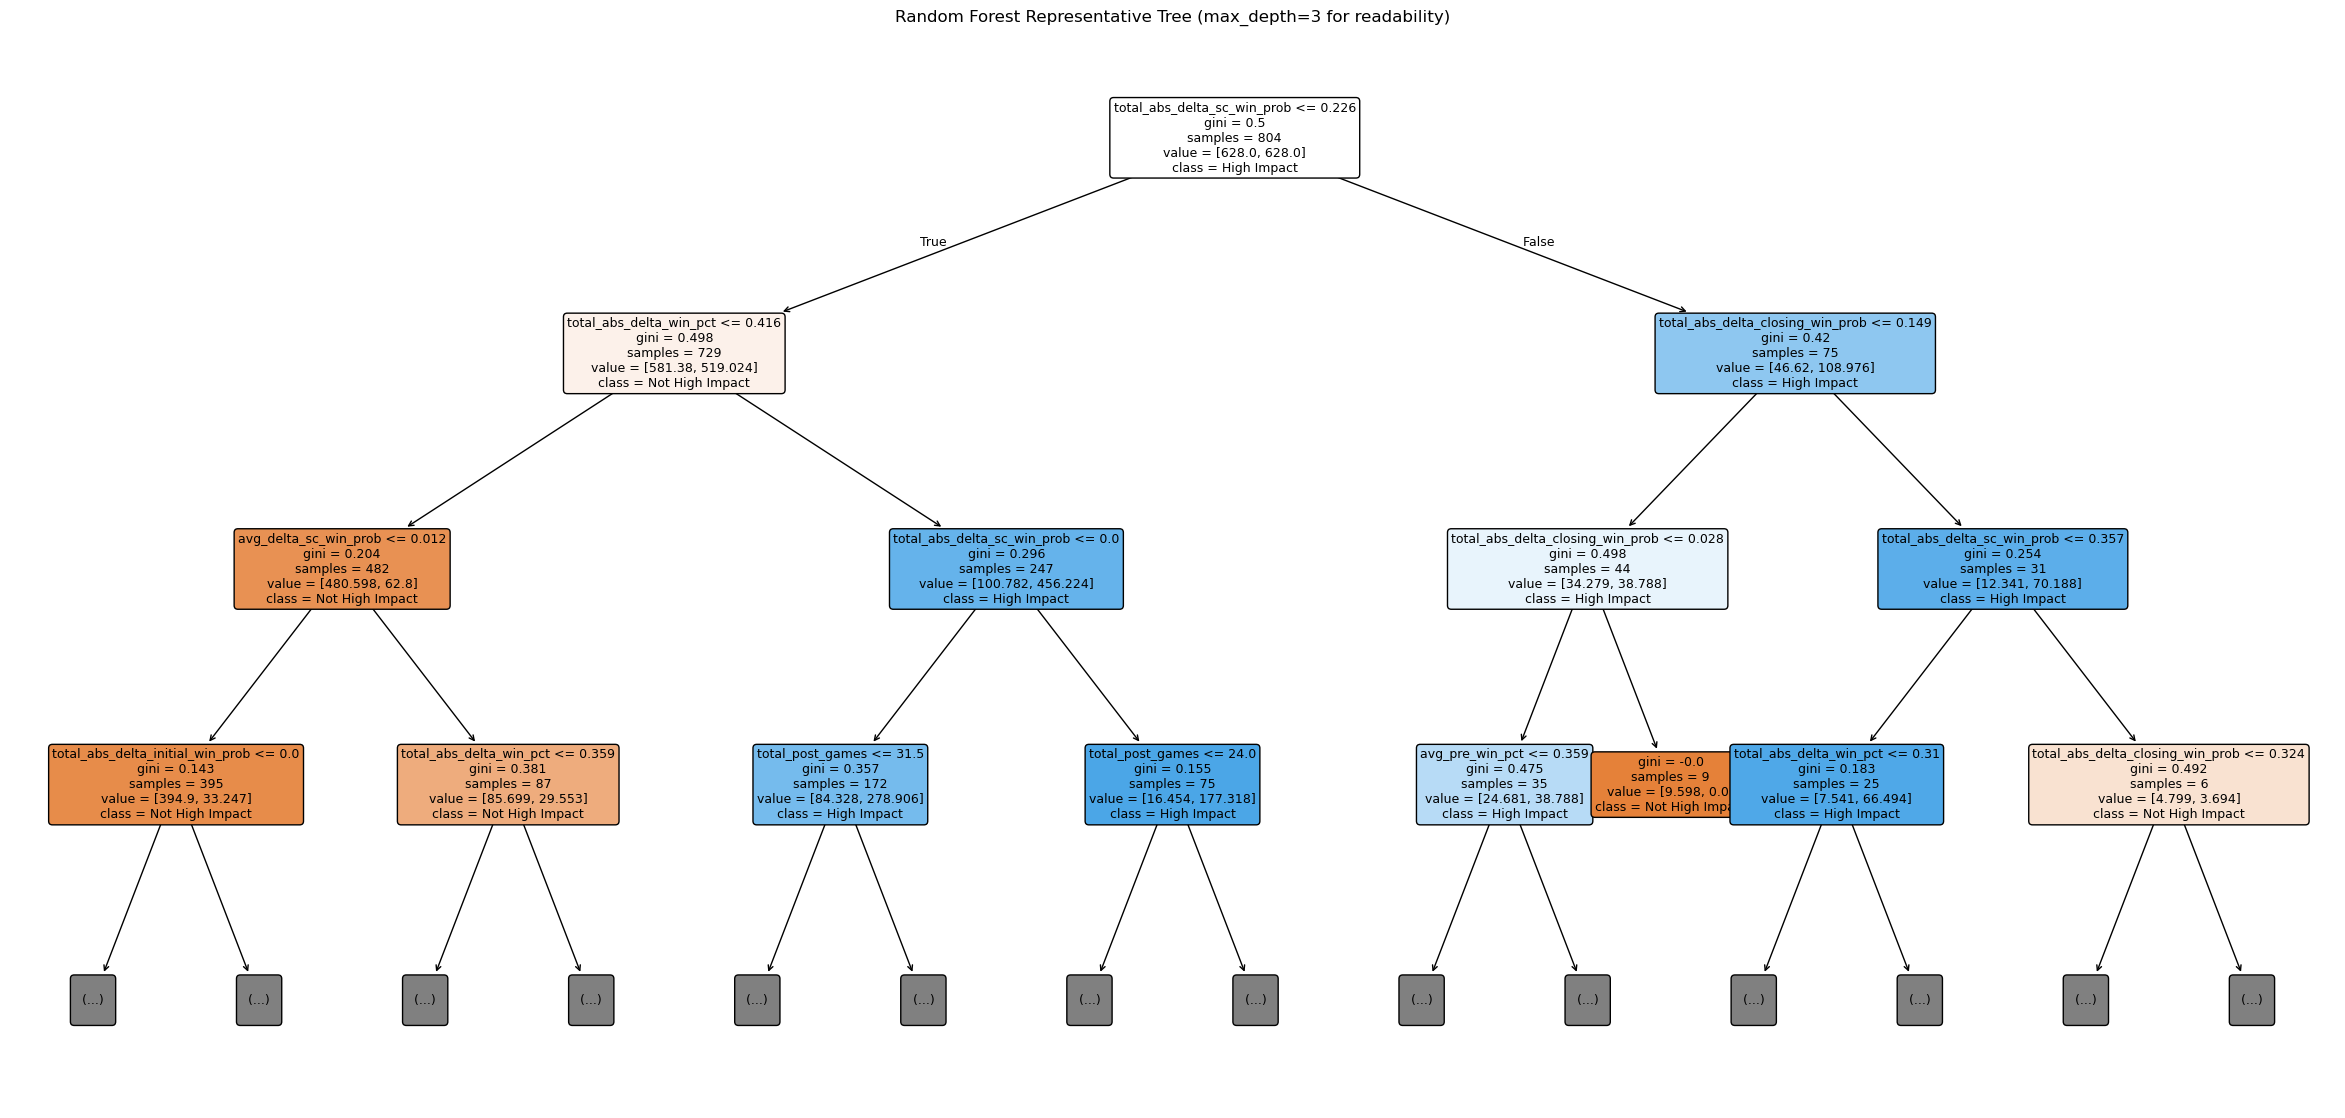

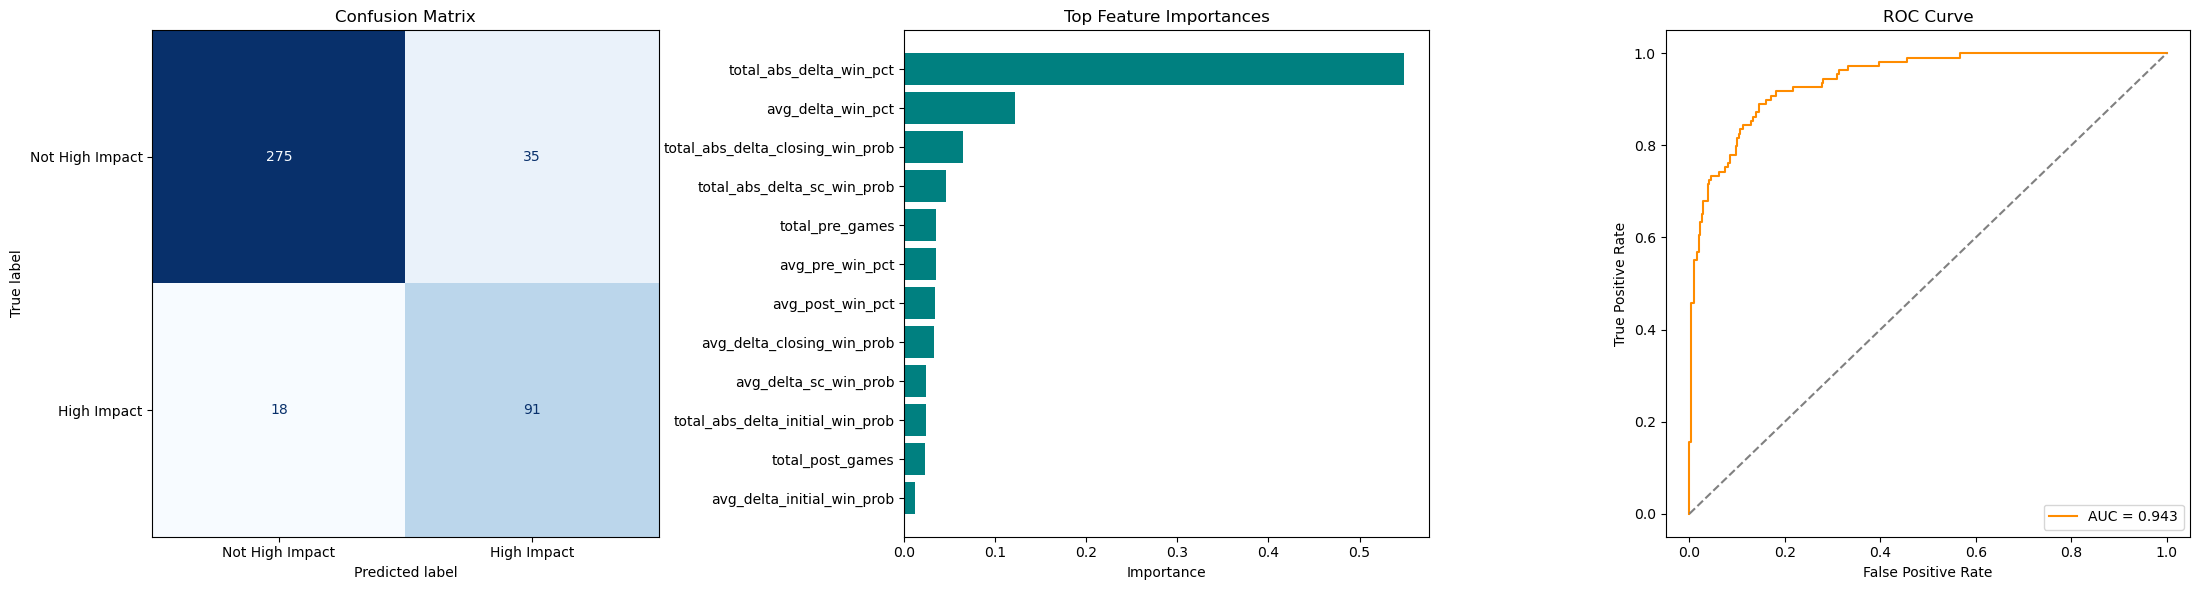

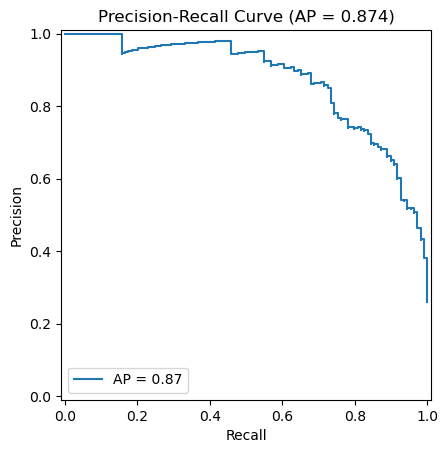

In [38]:
# Representative tree from the fitted forest
rf_estimator = rf_model.named_steps['model'].estimators_[0]

plt.figure(figsize=(30, 14))
plot_tree(
    rf_estimator,
    feature_names=feature_cols,
    class_names=['Not High Impact', 'High Impact'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title('Random Forest Representative Tree (max_depth=3 for readability)')
plt.show()

# Classification diagnostics
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not High Impact', 'High Impact']).plot(
    ax=axes[0],
    colorbar=False,
    cmap='Blues',
)
axes[0].set_title('Confusion Matrix')

fi_plot = feature_importance_df.sort_values('importance', ascending=True).tail(12)
axes[1].barh(fi_plot['feature'], fi_plot['importance'], color='teal')
axes[1].set_title('Top Feature Importances')
axes[1].set_xlabel('Importance')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)
axes[2].plot(fpr, tpr, label=f'AUC = {roc_auc_val:.3f}', color='darkorange')
axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Precision-recall view for class imbalance context
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap)
disp.plot()
plt.title(f'Precision-Recall Curve (AP = {ap:.3f})')
plt.show()

## Next Steps

- Add plots for the top and bottom trades in each season.
- Compare this ranking against offseason-only trades versus in-season trades.
- Export `trade_summary` and `trade_team_metrics` to CSV if you want to reuse the results in another notebook.